## Spaceship Titanic EDA

## Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from ydata_profiling import ProfileReport

/home/abdullah/Dev/Smaster 4/Ai Lab/PAI Lab 2/spaceship-titanic/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [4]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8693, 14)
Test shape: (4277, 13)


## Quick Look & EDA

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
<c

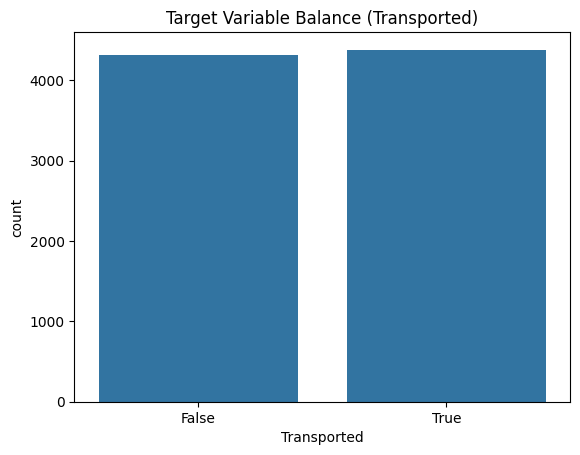

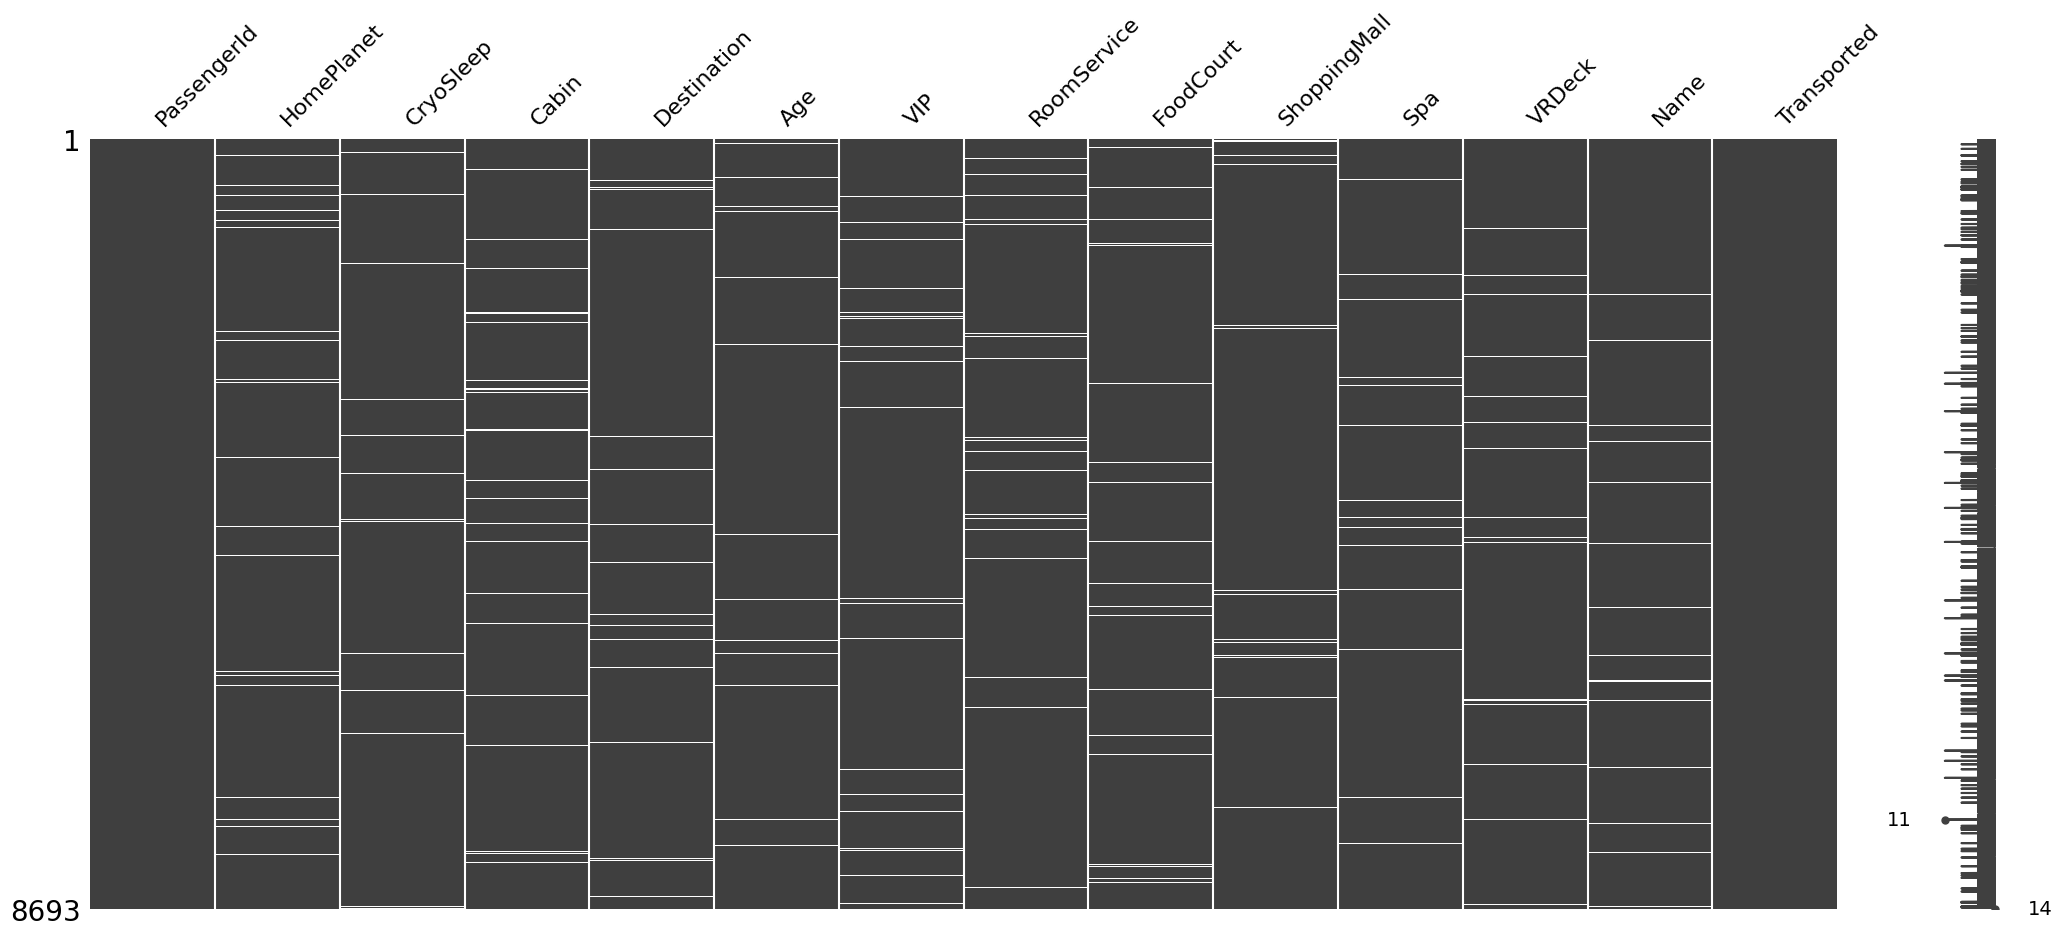

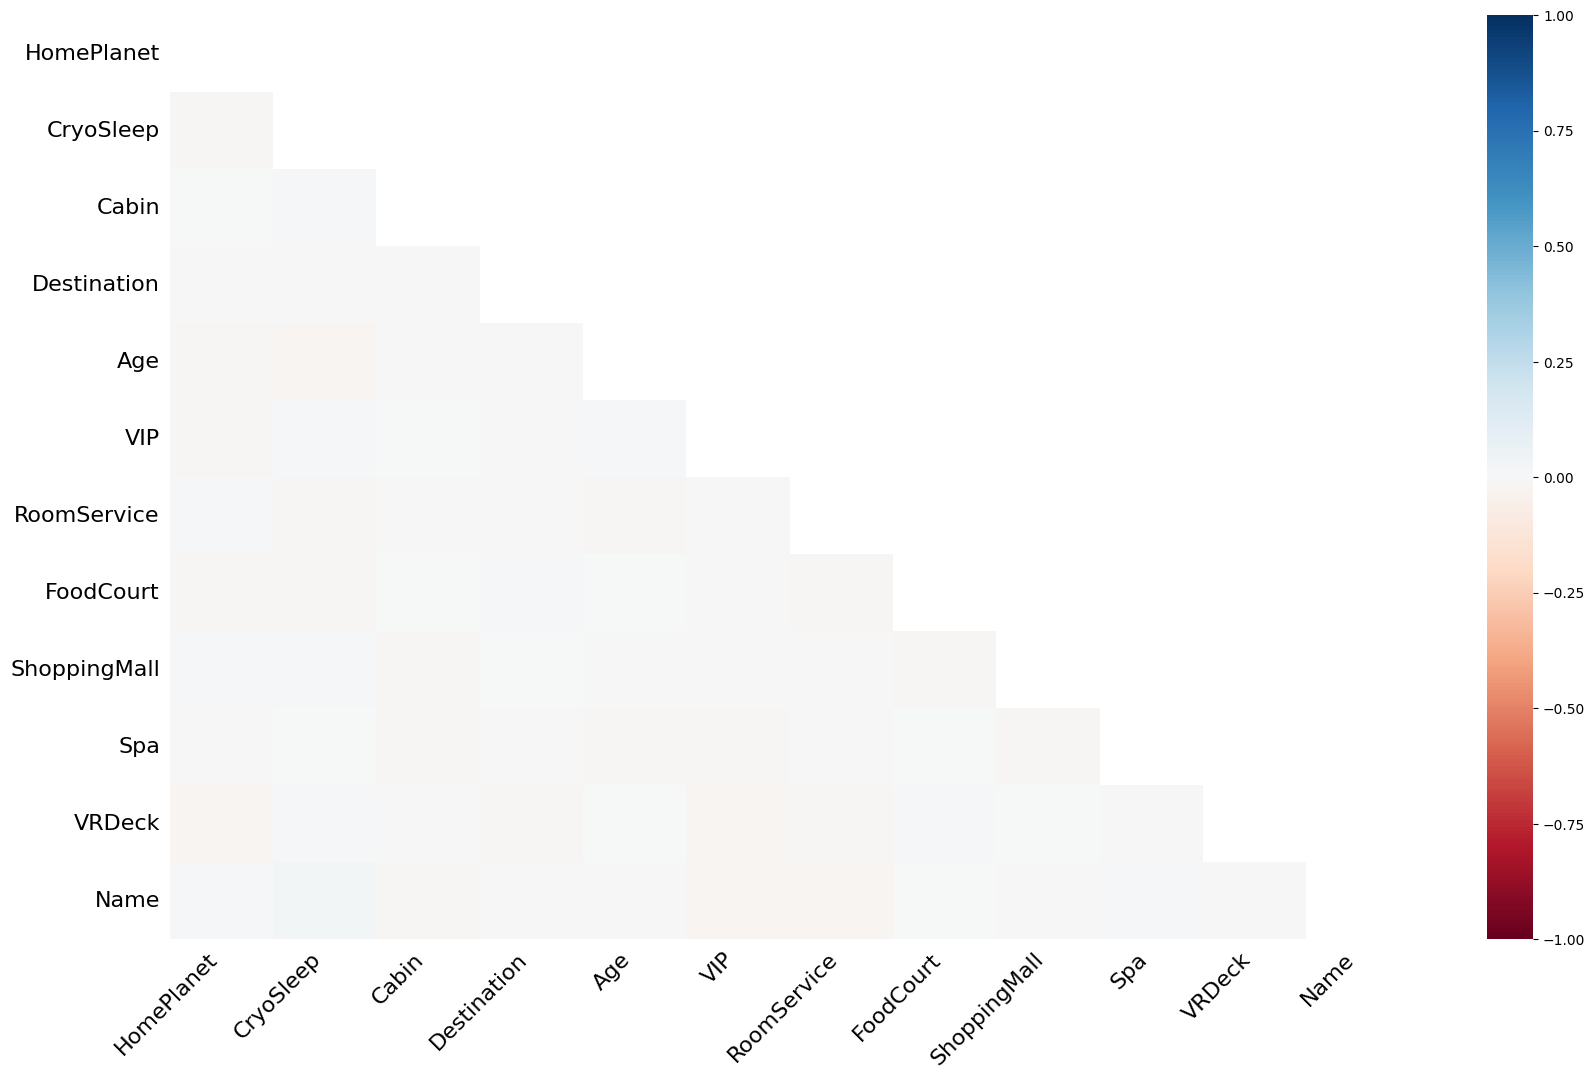

Render HTML: 100%|██████████| 1/1 [00:02<00:00,  2.39s/it]


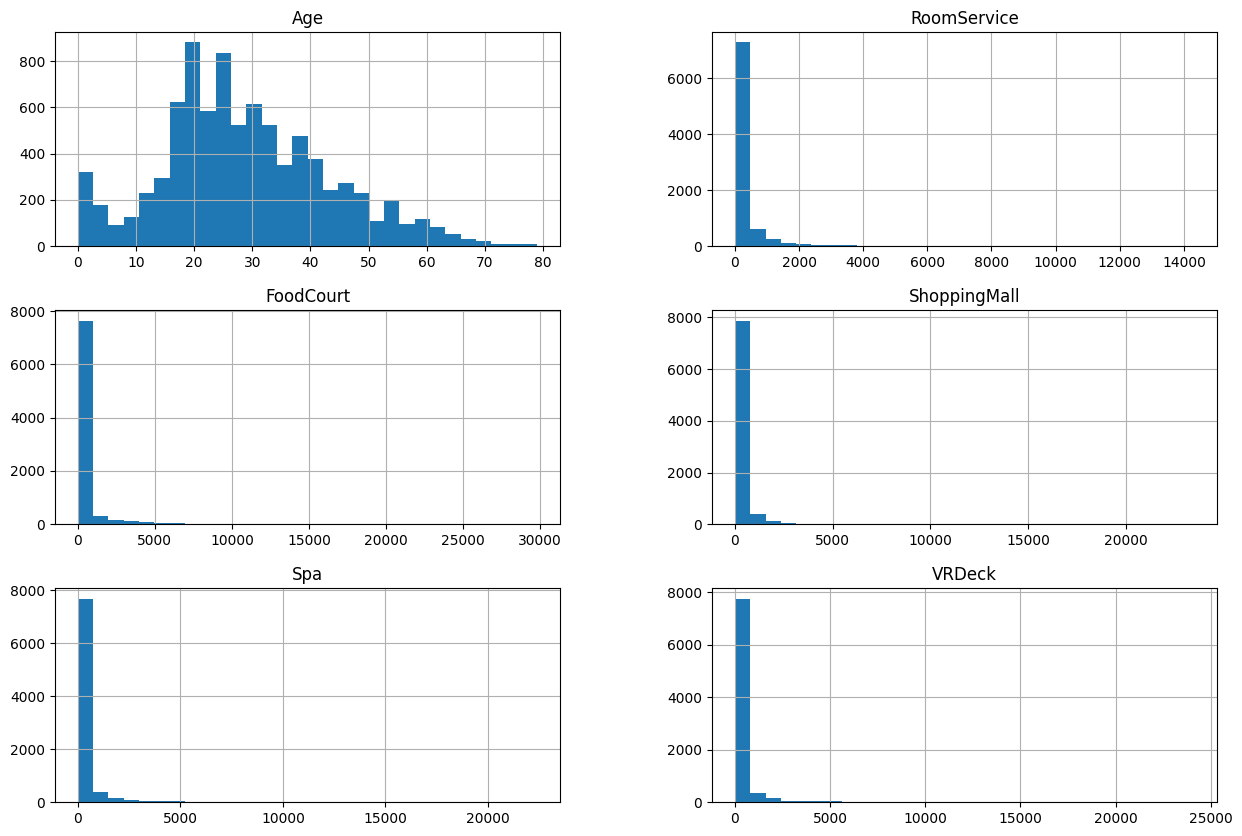

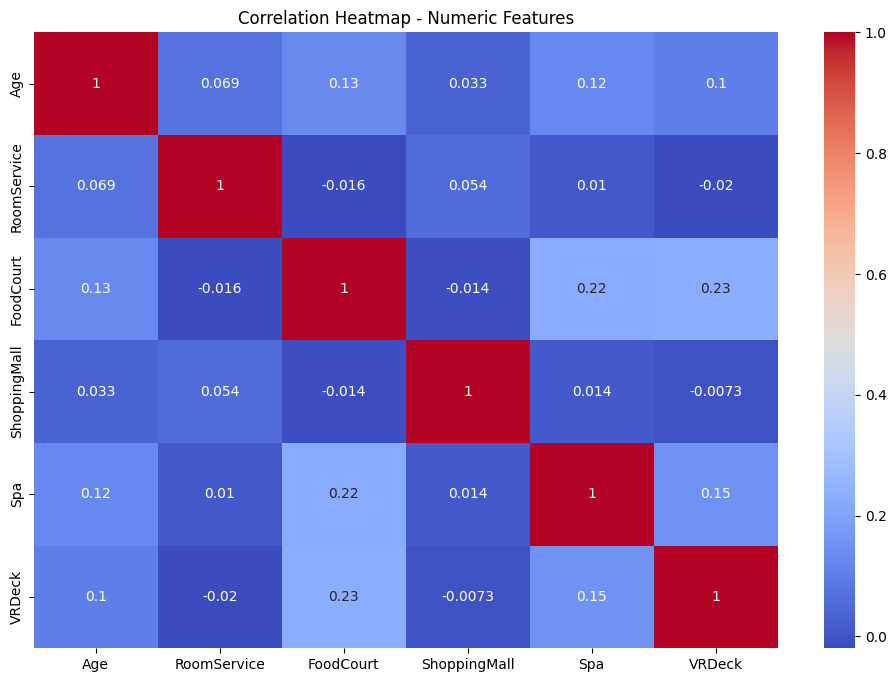

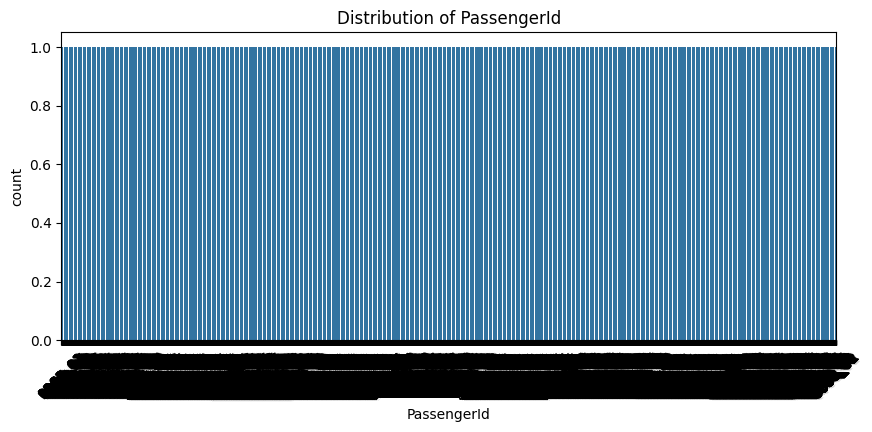

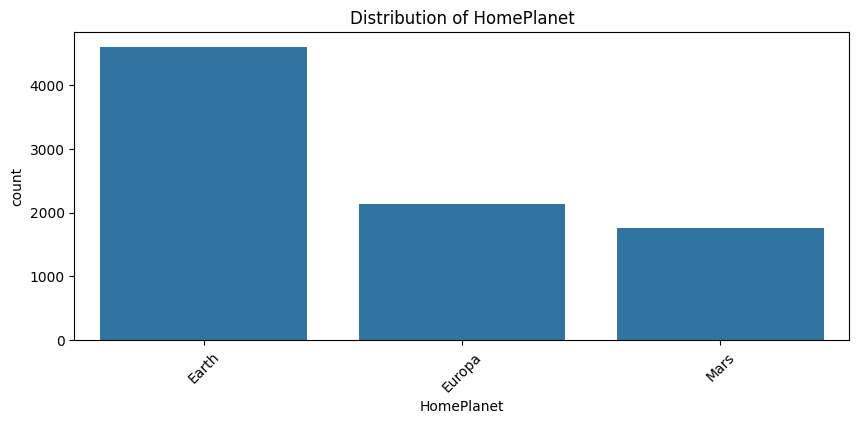

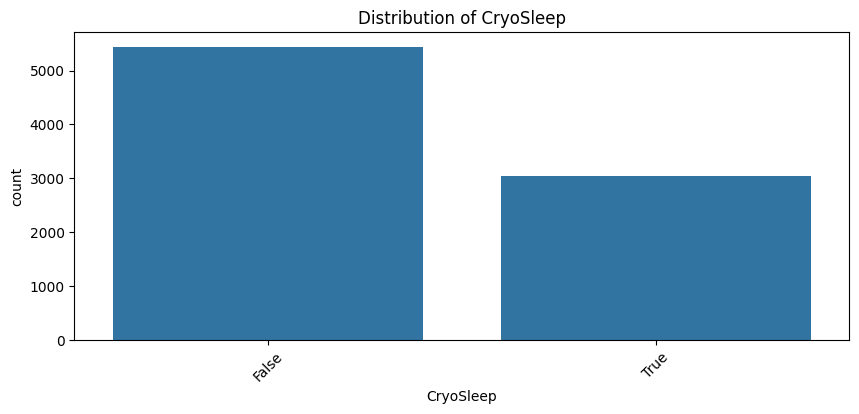

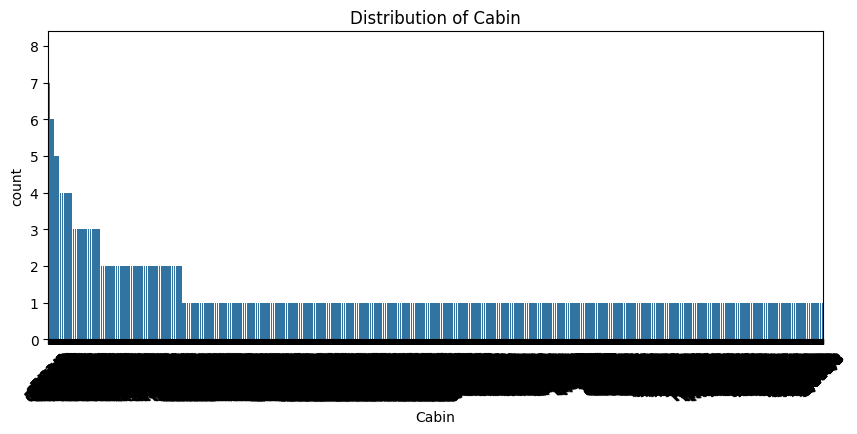

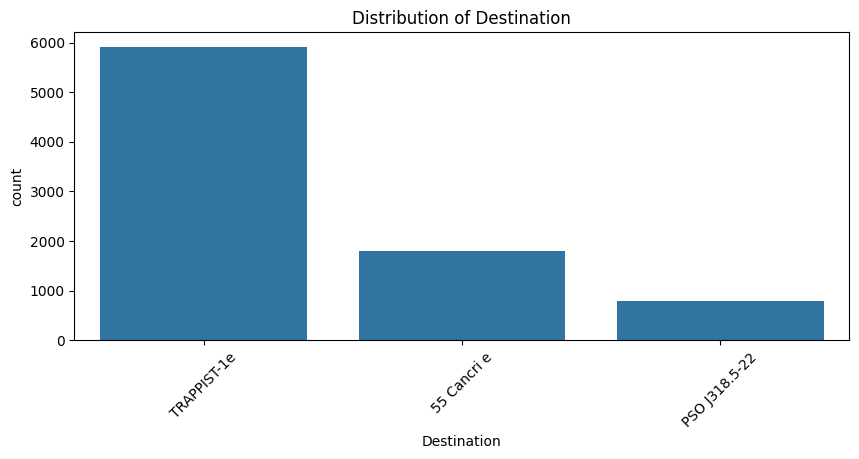

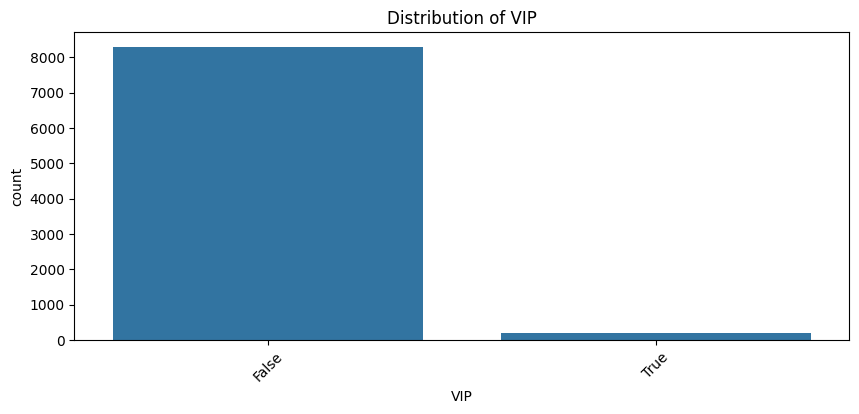

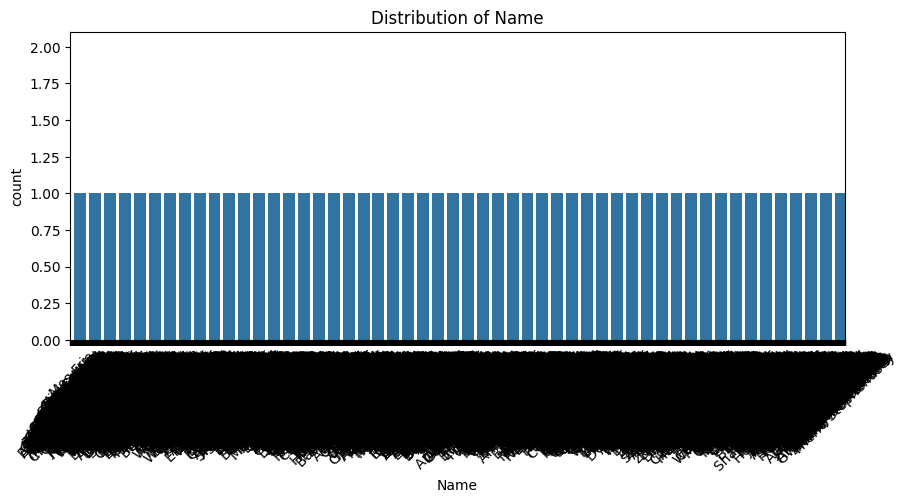

In [6]:
print(train.head())
print(train.info())
print(train.describe())


sns.countplot(x="Transported", data=train)
plt.title("Target Variable Balance (Transported)")
plt.show()


msno.matrix(train)
plt.show()

msno.heatmap(train)
plt.show()


profile = ProfileReport(train, title="Spaceship Titanic EDA Report", explorative=True)
profile.to_notebook_iframe()

num_cols = train.select_dtypes(include=np.number).columns
train[num_cols].hist(bins=30, figsize=(15, 10))
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(train[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Features")
plt.show()


cat_cols = train.select_dtypes(include="object").columns
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=train, order=train[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()
